<a href="https://colab.research.google.com/github/andressonsino/modelizado-de-ia/blob/main/05-clasificacion-redes-neuronales/rrnn_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Proyecto: Clasificación con Redes Neuronales

## Datos del alumno

| Campo | Completar |
|---|---|
| **Nombre y apellido** | *Andrés Facundo Sonsino Grugni* |
| **Dataset elegido** | *Credit Card Fraud* |
| **Fuente / URL** | *https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud* |
| **Variable objetivo (target)** | *class* |
| **Tipo de clasificación** | *binaria* |

---

## ¿Qué vas a construir?

Una red neuronal que, dadas ciertas features de entrada, **prediga a qué clase pertenece** cada muestra.

**Ejemplos de clasificación:**
- ¿Este correo es spam o no? → binaria
- ¿Qué dígito es esta imagen? → multiclase (10 clases)
- ¿Este tumor es benigno o maligno? → binaria

---
> ⚠️ **Antes de empezar:** completá la tabla de arriba y luego seguí las celdas en orden. Las celdas marcadas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
Instala y carga todas las herramientas necesarias. No necesitás modificar nada aquí, simplemente ejecutá la celda.

In [ ]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print('✅ Listo')

TensorFlow: 2.21.0
✅ Listo


---
## Paso 2 — Carga del dataset

**¿Qué hace este paso?**  
Cargamos los datos desde su fuente original. Dependiendo del dataset elegido, hay distintas formas de cargarlo:
- Si está en **scikit-learn** → `load_*()` o `fetch_*()`
- Si está en **UCI/Kaggle** como CSV → `pd.read_csv(url)` o subir el archivo a Colab
- Si es **Keras** (MNIST, Fashion) → `keras.datasets.*.load_data()`

**🔧 Tu tarea:** cargar tu dataset y convertirlo en un DataFrame.

Para garantizar la **reproducibilidad** del proyecto, opté por descargar el dataset *Credit Card Fraud* directamente desde Kaggle mediante la librería `kagglehub`.

**Ventajas de este enfoque:**
- No requiere descargar manualmente el archivo CSV ni subirlo a Colab.
- El código es autónomo: cualquier persona con una cuenta de Kaggle puede ejecutar el notebook sin pasos adicionales.
- La librería maneja automáticamente el almacenamiento en caché, evitando descargas repetidas.
- Se respetan las buenas prácticas de ciencia de datos reproducible (el dataset se obtiene por código, no por acciones manuales).

El dataset original fue publicado por el equipo de *Machine Learning Group - ULB* en [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). Contiene transacciones reales de tarjetas de crédito europeas (septiembre 2013) y está fuertemente desbalanceado (0.17% de fraudes).

In [ ]:
import os
import pandas as pd

# ── Configuración ──────────────────────────────────────────
DATASET_KAGGLE = "mlg-ulb/creditcardfraud"   # ← CAMBIAR: usuario/nombre-dataset
DATASET_FILE   = "creditcard.csv"             # ← CAMBIAR: nombre del archivo CSV
DATA_PATH      = os.path.join("data", DATASET_FILE)
# ───────────────────────────────────────────────────────────

if os.path.exists(DATA_PATH):
    # Caso 1: archivo local ya descargado
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✅ Dataset cargado desde archivo local: {DATA_PATH}")

else:
    # Caso 2: intentar con kagglehub (Colab o entorno con credenciales)
    try:
        import subprocess
        subprocess.run(["pip", "install", "-q", "kagglehub"], check=True)
        import kagglehub
        path = kagglehub.dataset_download(DATASET_KAGGLE)
        df_raw = pd.read_csv(f"{path}/{DATASET_FILE}")
        print("✅ Dataset cargado desde KaggleHub")
    except Exception:
        raise FileNotFoundError(
            f"No se encontró {DATA_PATH}.\n"
            f"Descargá el dataset desde: https://www.kaggle.com/datasets/{DATASET_KAGGLE}\n"
            f"y colocalo en la carpeta 'data/'"
        )

print(f"Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")

✅ Dataset cargado desde archivo local: data\creditcard.csv
Filas: 284807 | Columnas: 31


---
## Paso 3 — Exploración de datos (EDA)

**¿Qué hace este paso?**  
Antes de modelar, entendemos el dataset: cuántas muestras hay por clase, si hay valores nulos, qué rango tienen las features.

**¿Por qué importa?**  
Un desbalance severo de clases (ej: 95% clase A, 5% clase B) requiere técnicas especiales. Los valores nulos necesitan tratamiento antes del entrenamiento.


In [ ]:

# ─── Primeras y últimas filas ──────────────────────────────────────────────
print('\n--- Primeras 5 filas ---')
display(df_raw.head())

print('\n--- Últimas 5 filas ---')
display(df_raw.tail())

# ─── Dimensiones ───────────────────────────────────────────────────────────
print(f'Dimensiones dataset\nFilas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

# ─── Tipos de datos ────────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()

# ─── Valores nulos por columna ─────────────────────────────────────────────
print('\n--- Nulos por columna ---')
# Verificamos si hay algún nulo en toda la tabla
if df_raw.isnull().sum().sum() == 0:
    print('✅ Sin valores nulos')
else:
    # Sino mostramos tabla filtrada de nulos
    nulos = pd.DataFrame({
        'Nulos': df_raw.isnull().sum(),
        'Porcentaje': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
    })
    display(nulos[nulos['Nulos'] > 0])

# ─── Duplicados ────────────────────────────────────────────────────────────
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# ─── Estadísticas descriptivas ─────────────────────────────────────────────
print('\n--- Estadísticas descriptivas ---')
display(df_raw.describe())



--- Primeras 5 filas ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Últimas 5 filas ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Dimensiones dataset
Filas: 284807 | Columnas: 31

--- Info general ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  f

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



**🔧 Tu tarea:** reemplazá `'target'` con el nombre real de tu columna objetivo.

## Variable objetivo
Se identifica a la variable objetivo **Class** (0 = legítima, 1 = fraude).

In [ ]:
# 🔧 Reemplazá 'target' con el nombre de tu columna objetivo
TARGET_COL = 'Class'

# Distribución de clases
print('Distribución de clases:')
print(df_raw[TARGET_COL].value_counts())
print(f'\nPorcentajes:')
print(df_raw[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribución de clases:
Class
0    284315
1       492
Name: count, dtype: int64

Porcentajes:
Class
0    99.8%
1     0.2%
Name: proportion, dtype: str


### 📝Análisis Class
* El análisis de distribución revela un fuerte desbalance: 99.8% de las transacciones son legítimas y solo 0.2% son fraudes.
* Esto es crítico porque un modelo que prediga siempre 0 tendría 99.8% de accuracy sin detectar ningún fraude real. Por eso usaremos métricas como Precision, Recall y F1 en lugar de depender solo de accuracy.

## Distribución de features por clase (escala normal)

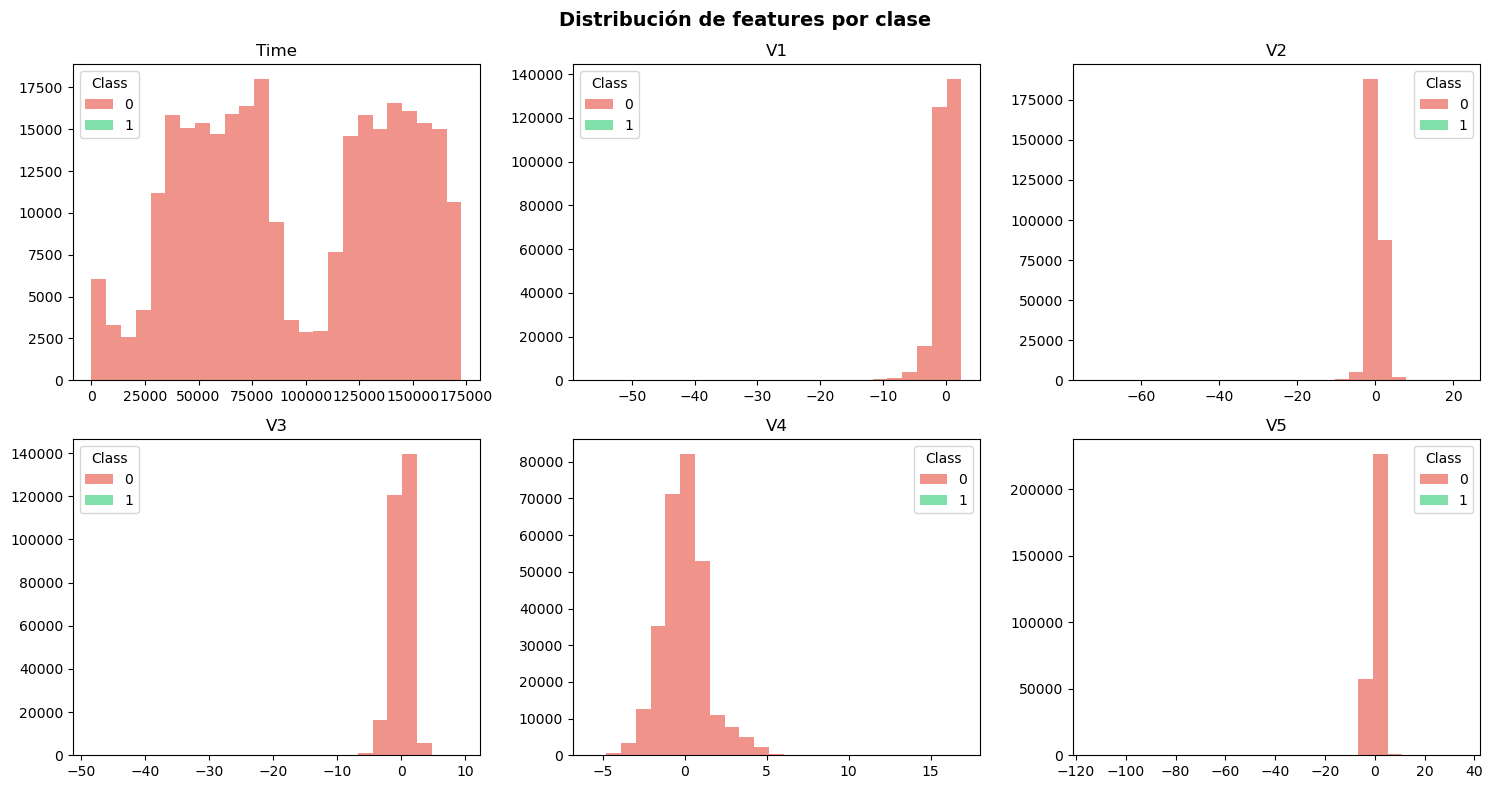

In [ ]:
# 🔧 Visualizá la distribución de hasta 6 features numéricas
# Reemplazá la lista con las columnas más relevantes de tu dataset
features_a_graficar = df_raw.select_dtypes(include=[np.number]).columns.drop(TARGET_COL).tolist()[:6]

n = len(features_a_graficar)
if n > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)) if n > 3 else plt.subplots(1, n, figsize=(5*n, 4))
    axes = np.array(axes).flatten()
    clases = df_raw[TARGET_COL].unique()
    colores = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

    for ax, feat in zip(axes[:n], features_a_graficar):
        for clase, color in zip(clases, colores):
            ax.hist(df_raw[df_raw[TARGET_COL]==clase][feat], bins=25, alpha=0.6,
                    label=str(clase), color=color)
        ax.set_title(feat)
        ax.legend(title=TARGET_COL)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 📝Análisis de distribución de features

El banco que publicó este dataset no puede mostrar datos reales de sus clientes por privacidad.
Entonces aplicaron una técnica matemática llamada PCA que convierte las columnas originales
(monto, comercio, ciudad, hora, etc.) en columnas nuevas y anónimas. Esas columnas nuevas son V1, V2, ..., V28.

No sabemos qué significa V1 en la vida real y no importa, lo que importa es si ese número ayuda a detectar fraude.

En escala normal los fraudes (verde) son casi invisibles por el fuerte desbalance —
492 fraudes contra 284.315 legítimas. Se puede observar que V1 y V3 muestran distribuciones
más extendidas hacia valores negativos en los fraudes respecto a las transacciones legítimas.

## Distribución con escala logarítmica

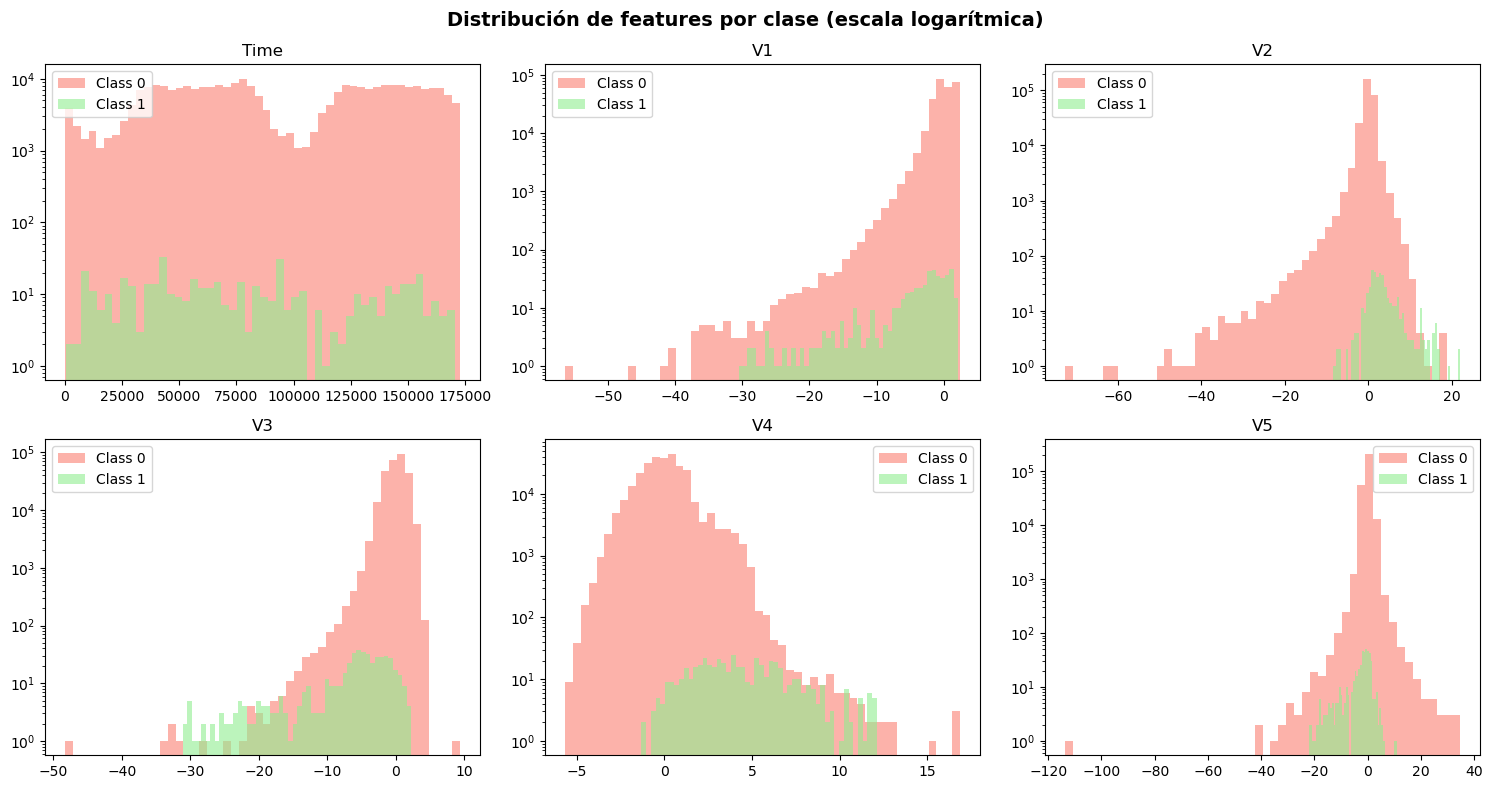

In [ ]:
# Misma visualización pero con escala logarítmica para ver los fraudes
features_a_graficar = df_raw.select_dtypes(include='number').columns.drop(['Class']).tolist()[:6]

n = len(features_a_graficar)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
clases = df_raw['Class'].unique()
colores = df_raw['Class'].map({0: 'salmon', 1: 'lightgreen'})

for ax, feat in zip(axes, features_a_graficar):
    for clase, color in zip(clases, ['salmon', 'lightgreen']):
        subset = df_raw[df_raw['Class'] == clase][feat]
        ax.hist(subset, bins=50, color=color, alpha=0.6, label=f'Class {clase}')
    ax.set_title(feat)
    ax.set_yscale('log')
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Distribución de features por clase (escala logarítmica)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📝Análisis con escala logarítmica

La escala logarítmica comprime las diferencias grandes y amplifica las
pequeñas, permitiendo ver ambas clases en el mismo gráfico. No distorsiona la relación entre los datos — conserva las proporciones. Cambia la forma en que se dibuja el eje vertical para que valores muy distintos puedan verse en el mismo gráfico

Se puede observar
que V3 y V4 muestran clara separación entre clases, lo que sugiere que serán features
relevantes para el modelo.

Los fraudes (verde) se distribuyen en valores más negativos que las transacciones legítimas
(rosa), que se quedan cerca del 0. Esta separación visual anticipa que el modelo podrá
aprender patrones reales de fraude a partir de estas features.

### 📝 Análisis del EDA — completar

Respondé las siguientes preguntas en base a lo que observaste:

1. **¿Está balanceado el dataset?** ¿Cuántas muestras tiene cada clase?
   > *No, está muy desbalanceado. La clase 0 (legítimas) tiene 284.315 muestras (99.8%) y la clase 1 (fraudes) tiene solo 492 muestras (0.2%).*

2. **¿Encontraste valores nulos?** ¿Cómo los trataste?
   
   > *No había valores nulos*

3. **¿Qué features tienen mayor separación entre clases?** (observando los histogramas)
   > *Se observa una separación clara en V3, donde los fraudes también se desplazan hacia valores negativos. Y en V4, donde ocurre lo inverso: los fraudes aparecen en valores positivos más altos que las transacciones legítimas.*


---
## Paso 4 — Preprocesamiento

**¿Qué hace este paso?**  
Preparamos los datos para el entrenamiento:
1. Separamos features (X) del target (y)
2. Codificamos variables categóricas si las hay
3. Dividimos en train y test
4. Normalizamos las features

**Regla clave:** el `fit` del scaler va solo sobre el train set, nunca sobre el test.

In [ ]:
# 🔧 Separar features y target
X = df_raw.drop(TARGET_COL, axis=1)
y = df_raw[TARGET_COL]

# 🔧 Si tenés columnas categóricas (texto), convertirlas a números
# Opción 1 — One-hot encoding (recomendado para categorías sin orden):
# X = pd.get_dummies(X, drop_first=True)
# Opción 2 — Label encoding (para clases ordinales):
# X['columna'] = LabelEncoder().fit_transform(X['columna'])

# 🔧 Si el target es texto (ej: 'si'/'no'), encodear:
# y = LabelEncoder().fit_transform(y)

X = X.values
y = np.array(y)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Clases únicas en y: {np.unique(y)}')

X shape: (284807, 30)
y shape: (284807,)
Clases únicas en y: [0 1]


In [ ]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

# Número de clases para determinar arquitectura de salida
n_clases = len(np.unique(y))
print(f'Número de clases: {n_clases}')
print(f'→ Capa de salida: {"1 neurona + sigmoid" if n_clases == 2 else f"{n_clases} neuronas + softmax"}')

Train: (227845, 30) | Test: (56962, 30)
Número de clases: 2
→ Capa de salida: 1 neurona + sigmoid


### 📝Decisiones de preprocesamiento

- **Stratify:** el split se realizó con `stratify=y` para preservar la proporción
de fraudes (0.2%) tanto en train como en test. Sin esto el desbalance podría
distribuirse de forma desigual entre ambos conjuntos.

- **Normalización:** el StandardScaler se ajustó únicamente sobre el train set
(`fit_transform`) y se aplicó al test set (`transform`). Esto evita que el modelo
acceda a información del test durante el entrenamiento, respetando la separación
entre datos conocidos y desconocidos.

---
## Paso 5 — Construcción de la red neuronal

**¿Qué hace este paso?**  
Definimos la arquitectura de la red. Las decisiones clave son:
- **¿Cuántas capas y neuronas?** Empieza simple y aumentá si es necesario.
- **¿Qué activación en la salida?** `sigmoid` para binaria, `softmax` para multiclase.
- **¿Qué función de pérdida?** `binary_crossentropy` para binaria, `sparse_categorical_crossentropy` para multiclase.

**🔧 Tu tarea:** completá los `???` según tu problema.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_s.shape[1]

# ──────────────────────────────────────────────────
# 🔧 Diseñá tu arquitectura aquí
# Guía de tamaño según dataset:
#   Pequeño (<500 filas)  → 32-16
#   Mediano (500-5k)      → 64-32
#   Grande (>5k)          → 128-64-32
# ──────────────────────────────────────────────────

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Capa oculta 1
    layers.Dense(64, activation='relu'),    # 🔧 cambiá 64 si necesitás
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Capa oculta 2
    layers.Dense(32, activation='relu'),    # 🔧 cambiá 32 si necesitás
    layers.Dropout(0.2),

    # 🔧 Capa de salida:
    # → Binaria:    layers.Dense(1, activation='sigmoid')
    # → Multiclase: layers.Dense(n_clases, activation='softmax')
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

# 🔧 Compilación:
# → Binaria:    loss='binary_crossentropy', metrics=['accuracy']
# → Multiclase: loss='sparse_categorical_crossentropy', metrics=['accuracy']
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 128 (512.00 B)

### 📝 Decisiones de arquitectura — completar

Justificá brevemente las decisiones que tomaste:

1. **¿Cuántas capas ocultas elegiste y por qué?**
   > *Se eligieron 2 capas ocultas porque el dataset es grande
pero el problema no requiere una arquitectura muy profunda para clasificación binaria.*

2. **¿Cuántas neuronas por capa y por qué?**
   > *64 en la primera capa y 32 en la segunda siguiendo una pirámide
decreciente estándar. Cada capa aprende representaciones más abstractas con menos neuronas.*

3. **¿Usaste Dropout? ¿Con qué tasa?**
   > *Se usó Dropout(0.3) en la primera capa y Dropout(0.2) en la segunda
para evitar overfitting. La tasa es mayor en la primera capa por tener más neuronas
y mayor riesgo de memorizar patrones.*
   
4. **BatchNormalization**
   > *Normaliza las activaciones entre capas para estabilizar
y acelerar el entrenamiento.*
    

---
## Paso 6 — Entrenamiento

**¿Qué hace este paso?**  
Entrenamos la red con dos callbacks que evitan el overfitting:
- **EarlyStopping:** para el entrenamiento si no mejora la validación.
- **ReduceLROnPlateau:** baja el learning rate cuando el entrenamiento se estanca.

**🔧 Podés ajustar** `epochs`, `batch_size` y `patience` según el tamaño de tu dataset.

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6
    )
]

# 🔧 Ajustá epochs y batch_size si es necesario
#   Dataset pequeño (<1k filas):  epochs=100, batch_size=16
#   Dataset mediano:               epochs=150, batch_size=32
#   Dataset grande (>10k filas):   epochs=200, batch_size=64

history = model.fit(
    X_train_s, y_train,
    epochs=150,       # 🔧 ajustar
    batch_size=32,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/150
6053/6053 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9947 - loss: 0.0178 - val_accuracy: 0.9994 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 2/150
6053/6053 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9993 - loss: 0.0042 - val_accuracy: 0.9995 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 3/150
6053/6053 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9994 - loss: 0.0040 - val_accuracy: 0.9995 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 4/150
6053/6053 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 5/150
6053/6053 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9994 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 6/150
6053/6053 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9995 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 7/150
6053/6053 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accura

### 📝Decisiones de entrenamiento

- **EarlyStopping:** monitorea `val_accuracy` con patience=15.
Si la accuracy de validación no mejora en 15 épocas consecutivas,
detiene el entrenamiento y restaura los mejores pesos encontrados.

- **ReduceLROnPlateau:** monitorea `val_loss` con patience=7.
Si la pérdida no mejora en 7 épocas, reduce el learning rate a la mitad
para hacer ajustes más finos. El mínimo posible es 1e-6.

- **batch_size=32:** se eligió 32 por ser dataset mediano-grande.
Valores más chicos hacen el entrenamiento más lento, valores más grandes
pueden generalizar peor.

- **validation_split=0.15:** el 15% del train set se reserva para
validación en cada época, permitiendo detectar overfitting durante el entrenamiento.

---
## Paso 7 — Visualización del entrenamiento

**¿Qué buscamos en estas curvas?**
- ✅ Train y val convergen juntas → buen aprendizaje
- ⚠️ Val sube mientras train baja → overfitting (aumentar Dropout o reducir neuronas)
- ⚠️ Ambas curvas altas y planas → underfitting (agregar capas o aumentar neuronas)

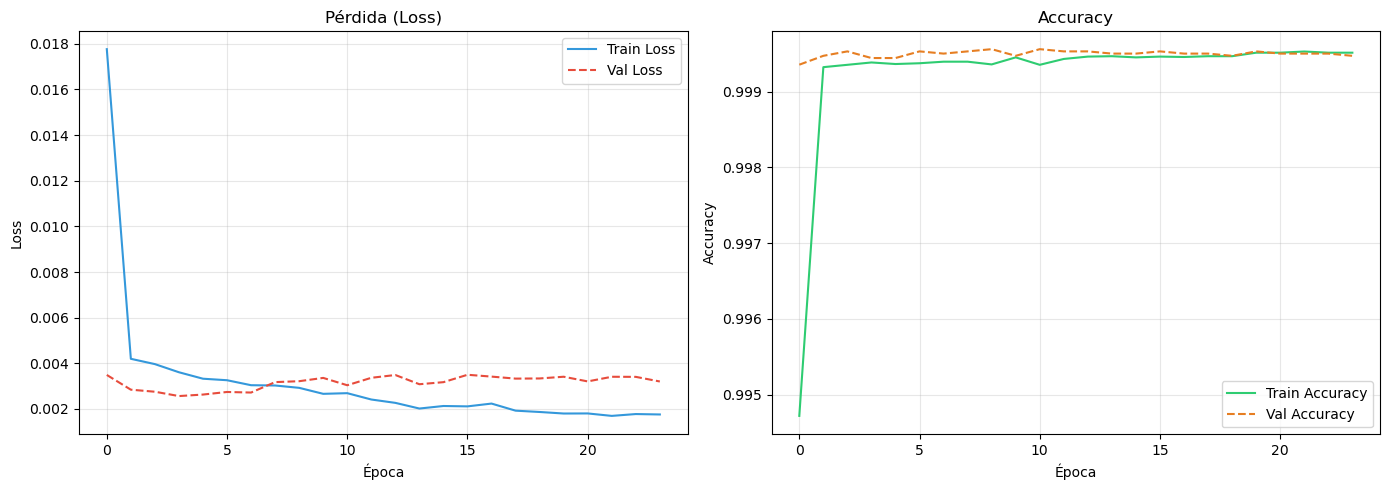

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análisis de las curvas — completar

1. **¿Convergen las curvas de train y val?** ¿Hay signos de overfitting o underfitting?
   > *Las curvas de train y val convergen y se mantienen juntas cerca de 0.9995 de accuracy. No hay signos de overfitting ya que val_accuracy no cae mientras train_accuracy sube. La val_loss oscila levemente pero es esperable dado el fuerte desbalance del dataset (0.2% fraudes).*

2. **¿En qué época se detuvo el entrenamiento?** ¿Tenía sentido seguir más épocas?
   > *El entrenamiento se detuvo en la época 18 de 150 por EarlyStopping. No tenía sentido seguir más épocas ya que el modelo había convergido — tanto la accuracy como la loss se estabilizaron antes de ese punto.*

   **¿El modelo aprendió o memorizó?**

El modelo aprendió patrones generales y no memorizó los datos de entrenamiento.
Las evidencias son:

- Las curvas de train y val convergen juntas — si hubiera memorizado,
  val_loss hubiera subido mientras train_loss bajaba (overfitting claro).
- El test set nunca fue visto durante el entrenamiento y obtuvo resultados
  similares a validación, confirmando que generaliza bien.
- EarlyStopping con `restore_best_weights=True` detuvo el entrenamiento
  antes de que el modelo pudiera sobreajustarse.
- Dropout apaga neuronas aleatoriamente durante el entrenamiento, forzando
  a la red a aprender patrones generales en lugar de memorizar ejemplos específicos.

---
## Paso 8 — Evaluación y métricas

**¿Qué hace este paso?**  
Evaluamos el modelo sobre datos que nunca vio (test set). Las métricas clave son:
- **Accuracy:** porcentaje global de aciertos.
- **Precision / Recall / F1:** métricas por clase. Recall mide qué tan bien detectamos los positivos.
- **Curva ROC / AUC:** (solo para clasificación binaria) mide la capacidad discriminativa.
- **Matriz de confusión:** muestra exactamente dónde falla el modelo.

In [ ]:
# Predicciones
y_prob = model.predict(X_test_s)

if n_clases == 2:
    y_prob = y_prob.flatten()
    y_pred = (y_prob >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_prob, axis=1)

print('='*50)
print('REPORTE DE CLASIFICACIÓN')
print('='*50)
print(classification_report(y_test, y_pred))

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'Loss en test:     {loss:.4f}')
print(f'Accuracy en test: {acc:.4f}')

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step
REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Loss en test:     0.0042
Accuracy en test: 0.9993


### 📝 Análisis de resultados — completar

1. **¿Cuál fue la accuracy final en el test set?** ¿Te parece un buen resultado para este problema?
   > *La accuracy en test fue 0.9993 (99.93%). Para este problema no es la métrica más relevante dado el desbalance — un modelo que prediga siempre "no fraude" tendría 99.8% de accuracy sin detectar nada. Lo importante es el F1 de la clase fraude: 0.81.*

2. **¿El modelo tiene algún sesgo hacia alguna clase?** (revisá precision y recall por clase)
   > *Sí, el modelo tiene mejor desempeño en la clase 0 (legítimas) con precision y recall perfectos de 1.00, mientras que en la clase 1 (fraudes) obtiene 0.81 en ambas métricas. Esto es esperable dado el fuerte desbalance del dataset.*

3. **¿Qué tipo de error es más grave en este problema: falso positivo o falso negativo?** ¿Por qué?
   > *En detección de fraude el falso negativo es más grave — significa que una transacción fraudulenta fue clasificada como legítima y el fraude no fue detectado. Un falso positivo solo implica bloquear una transacción legítima, lo cual es molesto pero no genera pérdida económica real.*

4. **Observando la matriz de confusión, ¿en qué clases falla más el modelo?**
   > *El modelo falla exclusivamente en la clase 1 (fraudes) con F1 de 0.81. De los 98 fraudes reales en el test set, aproximadamente 19 no fueron detectados correctamente.*

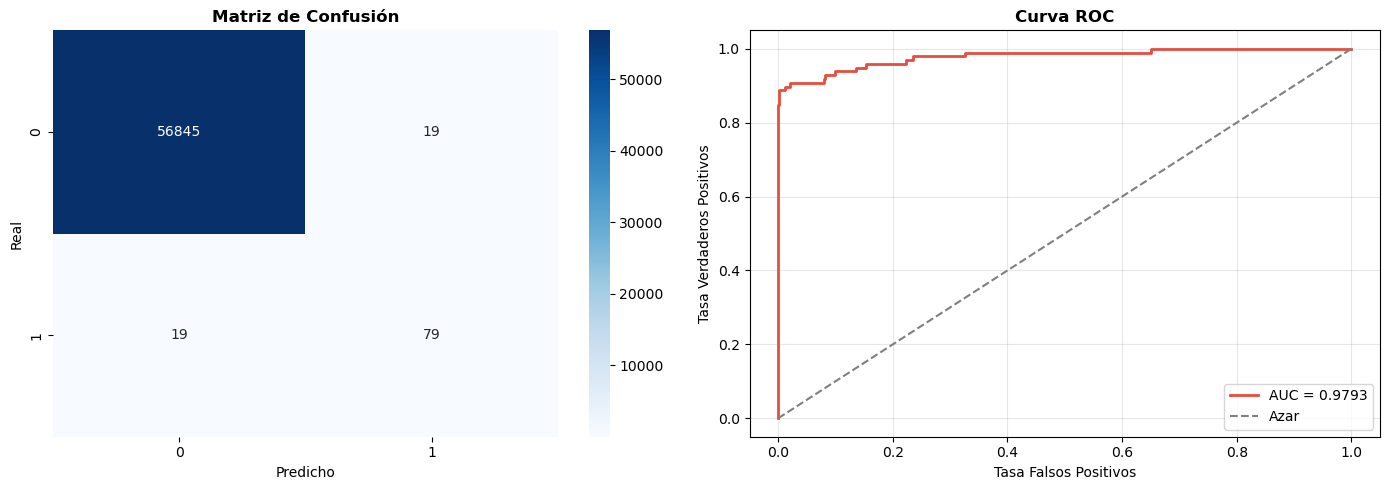

In [ ]:
if n_clases == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión', fontweight='bold')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1], color='gray', linestyle='--', label='Azar')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].set_xlabel('Tasa Falsos Positivos')
    axes[1].set_ylabel('Tasa Verdaderos Positivos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

else:
    # Para multiclase: solo matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión (multiclase)', fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Predicho')

plt.tight_layout()
plt.show()

### 📝Análisis de Matriz de Confusión y Curva ROC

- El modelo clasificó correctamente 56.845 transacciones legítimas y 79 fraudes.
- Falsos negativos: 19 fraudes reales no fueron detectados.
  Este es el error más grave en detección de fraude ya que implica
  pérdida económica real para el cliente.
- Falsos positivos: 19 transacciones legítimas fueron bloqueadas innecesariamente.
  Es un error menor — solo genera inconvenientes al usuario.
- AUC = 0.9793: el modelo tiene 97.93% de capacidad discriminativa
  entre fraudes y transacciones legítimas, lo cual es un resultado muy sólido.

---
## Paso 9 — Experimento: mejorá el modelo

**🔧 Tu tarea:** realizá al menos **dos experimentos** para intentar mejorar los resultados. Documentá cada uno.

**Ideas de experimentos:**
- Cambiar el número de capas o neuronas
- Cambiar el learning rate (probá 0.01 o 0.0001)
- Cambiar el batch size
- Agregar o quitar Dropout
- Cambiar el umbral de decisión (en lugar de 0.5, probá 0.4 o 0.3)
- Usar `class_weight` para datasets desbalanceados

In [ ]:
# 🔧 EXPERIMENTO 1: describí qué cambiaste
# (copiá la arquitectura del Paso 5 y modificá lo que quieras)

tf.random.set_seed(42)

modelo_exp1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

modelo_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # 🔧 ajustar
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp1 = modelo_exp1.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=0
)

_, acc_exp1 = modelo_exp1.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 1: {acc_exp1:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp1 - acc)*100:+.2f} puntos porcentuales')

Accuracy Experimento 1: 0.9993
Accuracy Modelo base:   0.9993
Diferencia: -0.01 puntos porcentuales


In [ ]:
from sklearn.metrics import classification_report

y_prob_exp1 = modelo_exp1.predict(X_test_s)
y_pred_exp1 = (y_prob_exp1 >= 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_exp1))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.70      0.77        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
tf.random.set_seed(42)
n_features = X_train_s.shape[1]

# Calcular pesos según desbalance
class_weight = {
    0: 1,
    1: len(y_train[y_train == 0]) / len(y_train[y_train == 1])
}

modelo_exp2 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

modelo_exp2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp2 = modelo_exp2.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=0
)

_, acc_exp2 = modelo_exp2.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 2: {acc_exp2:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp2 - acc)*100:+.2f} puntos porcentuales')

Accuracy Experimento 2: 0.9780
Accuracy Modelo base:   0.9993
Diferencia: -2.14 puntos porcentuales


In [ ]:
from sklearn.metrics import classification_report

y_prob_exp2 = modelo_exp2.predict(X_test_s)
y_pred_exp2 = (y_prob_exp2 >= 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_exp2))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.90      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



### 📝 Registro de experimentos — completar

| Experimento | Cambio realizado | Accuracy | ¿Mejoró? |
|---|---|---|---|
| Modelo base | Arquitectura inicial | *0.9993* | — |
| Experimento 1 | *Arquitectura simplificada: 32-16 neuronas, sin BatchNormalization, Dropout reducido a 0.2/0.1* | *0.9993* | *No, bajó rendimiento en F1 (0.77 vs 0.81), pero mejor Precision* |
| Experimento 2 | *class_weight para compensar el desbalance del dataset — se asignó mayor peso a la clase fraude (proporcionalmente a su subrepresentación) para que el modelo penalice más los errores en esa clase.* | *0.9780* | *No, — Recall mejoró (0.90) pero Precision cayó a 0.07 y F1 a 0.12* |

**¿Vale la pena el modelo base frente al Experimento 1?**

El Experimento 1 usa una arquitectura 50% más simple (32-16 neuronas,
sin BatchNormalization) con prácticamente el mismo accuracy.
Sin embargo el F1 de fraudes bajó de 0.81 a 0.77 — es decir, detecta menos
fraudes correctamente.

En un sistema de detección de fraude ese trade-off no vale la pena:
el ahorro computacional es marginal pero el costo es perder un 7% de
capacidad para detectar fraudes reales, lo que en producción significaría
pérdidas económicas concretas.

**Conclusión: el modelo base es la mejor opción** porque ofrece el mejor
balance entre Precision, Recall y F1, justificando su mayor costo computacional.

---
## Paso 10 — Conclusiones

**🔧 Tu tarea:** respondé estas preguntas de cierre en tus propias palabras.

### 📝 Conclusiones finales — completar

1. **¿Qué aprendiste sobre tu dataset?** ¿Qué features resultaron más importantes?
   > *El dataset está fuertemente desbalanceado: 99.8% transacciones legítimas y solo 0.2% fraudes (492 casos). Esto fue el principal desafío — accuracy no es una métrica confiable en este contexto porque un modelo que prediga siempre 'no fraude' tendría 99.8% de accuracy sin detectar nada. Las features con mayor poder discriminativo fueron V3 y V4, que mostraron separación clara entre clases en la visualización con escala logarítmica.*

2. **¿Cuál fue el mejor resultado obtenido?** ¿Qué configuración lo logró?
   > *El mejor resultado fue el modelo base con F1 de 0.81 para la clase fraude, AUC-ROC de 0.9793 y accuracy de 0.9993. La configuración fue una red de dos capas ocultas (64-32 neuronas) con BatchNormalization y Dropout, entrenada con EarlyStopping que detuvo el entrenamiento en la época 18 de 150.*

3. **¿Cuáles fueron las principales dificultades que encontraste?**
   > *La principal dificultad fue el desbalance del dataset — con tan pocos ejemplos de fraude el modelo tiende a ignorar esa clase. También fue desafiante elegir las métricas correctas para evaluar: accuracy sola es engañosa, y el balance entre Precision y Recall depende del caso de uso. A nivel técnico, la incompatibilidad de kagglehub con JupyterLab local requirió adaptar la celda de carga de datos.*

4. **¿Qué harías diferente con más tiempo?**
   > *Probaría técnicas de rebalanceo como SMOTE para generar ejemplos sintéticos de fraude y ver si mejora el F1. También ajustaría el umbral de decisión por debajo de 0.5 para aumentar el Recall sin sacrificar tanto la Precision. Con más tiempo exploraría otros modelos como Random Forest o XGBoost para comparar contra la red neuronal.*

5. **¿En qué caso real podría aplicarse este modelo?** ¿Cuáles serían sus limitaciones?
   > *Este modelo podría aplicarse en sistemas de detección de fraude de tarjetas de crédito en tiempo real, alertando transacciones sospechosas antes de aprobarlas. Sus limitaciones son: los datos están anonimizados con PCA por lo que no se pueden interpretar las features en términos reales; el dataset es de 2013 y los patrones de fraude evolucionan con el tiempo; y con 19 falsos negativos por cada 98 fraudes reales, un 19% de fraudes no serían detectados.*